<a href="https://colab.research.google.com/github/arthurweslen/PowerQuery_DAX/blob/main/Visuals/Card_Header_Colorido_HTML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Card-header-colorido

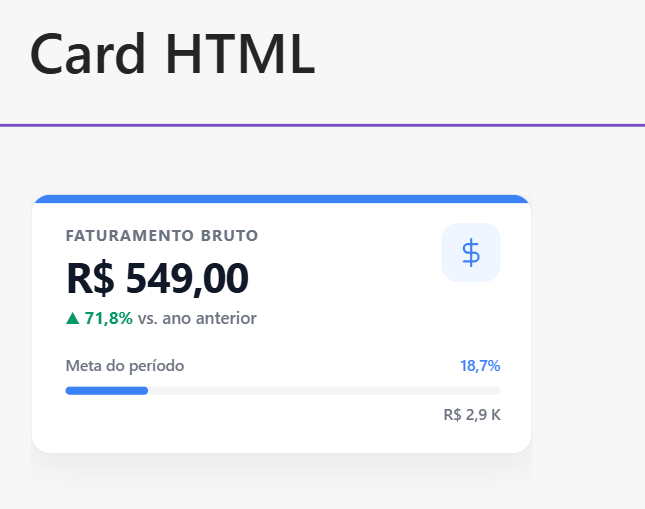

In [ ]:
HTML card-header-colorido=
//======================================================
//==================== VALORES ========================
VAR Fat         = [faturamento_bruto]
VAR Meta        = [faturamento_bruto_meta]
VAR YoY         = [faturamento_bruto YoY %]
VAR Ating       = [%atingimento_meta]

//======================================================



-- ╔══════════════════════════════════════════════════════════════════╗
-- ║                  🎨 PAINEL DE CONTROLE VISUAL                   ║
-- ║   Ajuste tudo aqui sem precisar mexer no HTML lá embaixo        ║
-- ╚══════════════════════════════════════════════════════════════════╝

-- ──────── 🏷️ TEXTOS ────────
VAR varTitulo           = "Faturamento Bruto"
VAR varLabelMeta        = "Meta do período"
VAR varComparativo      = "vs. ano anterior"

-- ──────── 🎨 CORES ────────
VAR CorFundo            = "#FFFFFF"
VAR CorBorda            = "#E5E7EB"
VAR CorTitulo           = "#6B7280"
VAR CorValor            = "#111827"
VAR CorBarraFundo       = "#F3F4F6"
VAR CorPosi             = "#059669"
VAR CorNega             = "#DC2626"
VAR CorBarra100         = "#059669"
VAR CorBarraAbaixo      = "#3B82F6"

-- ──────── 🌈 DETALHE COLORIDO NA BORDA ────────
VAR PosicaoDetalhe      = "topo"
VAR LarguraDetalhe      = "6px"
VAR DetalheDinamico     = TRUE()
VAR CorDetalheFixa      = "#3B82F6"
VAR SombraCard          = "0 8px 24px rgba(17,24,39,.06)"

-- ──────── 🎨 ÍCONE ────────
VAR PosicaoIcone        = "direita"
VAR IconePath =
    "M12 1v22M17 5H9.5a3.5 3.5 0 000 7h5a3.5 3.5 0 010 7H6"

VAR TamanhoCaixaIcone  = "42px"
VAR RaioCaixaIcone     = "12px"
VAR StrokeIcone        = "1.8"
VAR CorFundoIconePosi  = "#ECFDF5"
VAR CorIconePosi       = "#059669"
VAR CorFundoIconeNega  = "#EFF6FF"
VAR CorIconeNega       = "#3B82F6"

-- ──────── 📐 LAYOUT ────────
VAR RaioBorda           = "14px"
VAR Padding             = "20px 22px 20px 24px"

-- ──────── 📏 TIPOGRAFIA ────────
VAR FonteGlobal         = "'Segoe UI', system-ui, sans-serif"
VAR TamanhoTitulo       = "11px"
VAR TamanhoValor        = "30px"
VAR TamanhoVariacao     = "12px"
VAR TamanhoMeta         = "11px"

-- ──────── 🎯 BARRA DE META ────────
VAR AlturaBarraPx       = "6"
VAR RaioBarraPx         = "999"
VAR AnimarBarra         = TRUE()
VAR DuracaoAnimacao     = "1.4s"

-- ──────── 🔢 FORMATAÇÃO ────────
VAR AbreviarValores     = TRUE()
VAR CasasDecimais       = "1"


-- ╔══════════════════════════════════════════════════════════════════╗
-- ║                   ⚙️ LÓGICA DE NEGÓCIO                          ║
-- ╚══════════════════════════════════════════════════════════════════╝

VAR Posi        = YoY >= 0
VAR MetaOk      = Ating >= 1
VAR _fmt        = "#,##0." & REPT("0", VALUE(CasasDecimais))
VAR FatAbs      = ABS(Fat)
VAR MetaAbs     = ABS(Meta)
VAR PctBarraNum = MIN(1, MAX(0, Ating)) * 100
VAR PctBarra    = FORMAT(PctBarraNum, "0") & "%"
VAR FatFmt =
    IF(AbreviarValores,
        SWITCH(TRUE(),
            FatAbs >= 1000000000, "R$ " & FORMAT(Fat/1000000000,_fmt) & " B",
            FatAbs >= 1000000,    "R$ " & FORMAT(Fat/1000000,   _fmt) & " M",
            FatAbs >= 1000,       "R$ " & FORMAT(Fat/1000,      _fmt) & " K",
            "R$ " & FORMAT(Fat,"#,##0.00")),
        "R$ " & FORMAT(Fat,"#,##0.00"))

VAR MetaFmt =
    IF(AbreviarValores,
        SWITCH(TRUE(),
            MetaAbs >= 1000000000, "R$ " & FORMAT(Meta/1000000000,_fmt) & " B",
            MetaAbs >= 1000000,    "R$ " & FORMAT(Meta/1000000,   _fmt) & " M",
            MetaAbs >= 1000,       "R$ " & FORMAT(Meta/1000,      _fmt) & " K",
            "R$ " & FORMAT(Meta,"#,##0.00")),
        "R$ " & FORMAT(Meta,"#,##0.00"))

VAR YoYFmt      = FORMAT(ABS(YoY),"0.0%")
VAR AtingFmt    = FORMAT(Ating,"0.0%")
VAR CorStatus   = IF(Posi,   CorPosi,      CorNega)
VAR CorBarra    = IF(MetaOk, CorBarra100,  CorBarraAbaixo)
VAR CorDetalhe  = IF(DetalheDinamico, CorBarra, CorDetalheFixa)
VAR CorFundoIcon = IF(MetaOk, CorFundoIconePosi, CorFundoIconeNega)
VAR CorIcon      = IF(MetaOk, CorIconePosi,      CorIconeNega)
VAR Seta        = IF(Posi, "▲", "▼")
VAR DetalheCss =
    SWITCH(TRUE(),
        PosicaoDetalhe = "direita",
            ".card:before{content:'';position:absolute;right:0;top:0;bottom:0;width:" & LarguraDetalhe & ";background:" & CorDetalhe & ";}",
        PosicaoDetalhe = "topo",
            ".card:before{content:'';position:absolute;left:0;right:0;top:0;height:" & LarguraDetalhe & ";background:" & CorDetalhe & ";}",
        PosicaoDetalhe = "baixo",
            ".card:before{content:'';position:absolute;left:0;right:0;bottom:0;height:" & LarguraDetalhe & ";background:" & CorDetalhe & ";}",
        PosicaoDetalhe = "nenhuma",
            ".card:before{content:none;}",
            ".card:before{content:'';position:absolute;left:0;top:0;bottom:0;width:" & LarguraDetalhe & ";background:" & CorDetalhe & ";}"
    )

VAR Icone =
    "<svg width='21' height='21' viewBox='0 0 24 24' fill='none' " &
    "stroke='" & CorIcon & "' stroke-width='" & StrokeIcone & "' " &
    "stroke-linecap='round' stroke-linejoin='round'>" &
    "<path d='" & IconePath & "'/></svg>"

VAR IconeHtml =
    "<div class='icone-wrap'>" & Icone & "</div>"

VAR IconeEsquerda =
    IF(PosicaoIcone = "esquerda", IconeHtml, "")

VAR IconeDireita =
    IF(PosicaoIcone = "direita", IconeHtml, "")

VAR HeaderClasse =
    IF(PosicaoIcone = "nenhum", "topo sem-icone", "topo")

VAR AnimacaoBarraCss =
    IF(AnimarBarra,
        "animation:progressAnimationCard4 " & DuracaoAnimacao & " cubic-bezier(.22,.61,.36,1) both;",
        ""
    )

VAR KeyframesBarraCss =
    IF(AnimarBarra,
        "@keyframes progressAnimationCard4{from{width:0%;}to{width:" & PctBarra & ";}}",
        ""
    )


RETURN
"<!DOCTYPE html><html lang='pt-BR'><head><meta charset='UTF-8'>
<style>
  html,body{
    margin:0;padding:0;width:100%;height:100%;
    font-family:" & FonteGlobal & ";
    background:transparent;display:flex;align-items:center;justify-content:center;
  }
  .card{
    position:relative;overflow:hidden;
    background:" & CorFundo & ";border:1px solid " & CorBorda & ";
    border-radius:" & RaioBorda & ";padding:" & Padding & ";
    width:100%;height:100%;box-sizing:border-box;
    display:flex;flex-direction:column;justify-content:space-between;
    box-shadow:" & SombraCard & ";
  }
  " & DetalheCss & "
  .topo{display:flex;align-items:flex-start;justify-content:space-between;gap:12px;min-width:0;}
  .topo.sem-icone{display:block;}
  .header{display:flex;flex-direction:column;gap:6px;min-width:0;flex:1;}
  .label{font-size:" & TamanhoTitulo & ";font-weight:700;text-transform:uppercase;letter-spacing:.09em;color:" & CorTitulo & ";white-space:nowrap;}
  .value{font-size:" & TamanhoValor & ";font-weight:750;color:" & CorValor & ";letter-spacing:-1.1px;line-height:1;white-space:nowrap;}
  .yoy{font-size:" & TamanhoVariacao & ";font-weight:700;color:" & CorStatus & ";white-space:nowrap;}
  .comp{font-size:" & TamanhoVariacao & ";color:" & CorTitulo & ";font-weight:500;}
  .icone-wrap{width:" & TamanhoCaixaIcone & ";height:" & TamanhoCaixaIcone & ";min-width:" & TamanhoCaixaIcone & ";border-radius:" & RaioCaixaIcone & ";background:" & CorFundoIcon & ";display:flex;align-items:center;justify-content:center;flex-shrink:0;}
  .meta-row{display:flex;justify-content:space-between;align-items:center;margin-top:16px;gap:10px;}
  .meta-label{font-size:" & TamanhoMeta & ";color:" & CorTitulo & ";font-weight:500;white-space:nowrap;}
  .meta-pct{font-size:" & TamanhoMeta & ";font-weight:600;color:" & CorBarra & ";white-space:nowrap;}
  .bar-bg{background:" & CorBarraFundo & ";border-radius:" & RaioBarraPx & "px;height:" & AlturaBarraPx & "px;width:100%;margin-top:7px;overflow:hidden;}
  .bar-fill{height:100%;border-radius:" & RaioBarraPx & "px;background:" & CorBarra & ";width:" & PctBarra & ";" & AnimacaoBarraCss & "}
  " & KeyframesBarraCss & "
  .meta-val{font-size:" & TamanhoMeta & ";color:" & CorTitulo & ";margin-top:5px;text-align:right;font-weight:500;}
</style></head><body>
<div class='card'>
  <div class='" & HeaderClasse & "'>
    " & IconeEsquerda & "
    <div class='header'>
      <div class='label'>" & varTitulo & "</div>
      <div class='value'>" & FatFmt & "</div>
      <div class='yoy'>" & Seta & " " & YoYFmt & " <span class='comp'>" & varComparativo & "</span></div>
    </div>
    " & IconeDireita & "
  </div>
  <div>
    <div class='meta-row'>
      <span class='meta-label'>" & varLabelMeta & "</span>
      <span class='meta-pct'>" & AtingFmt & "</span>
    </div>
    <div class='bar-bg'><div class='bar-fill'></div></div>
    <div class='meta-val'>" & MetaFmt & "</div>
  </div>
</div>
</body></html>"
